# Notebook 08 — Classical Relation Extraction on DDI Corpus

**Goal:** Given a sentence with two drug names, predict what kind of drug-drug interaction (DDI) exists between them.

**The 5 DDI labels are:** `none`, `mechanism`, `effect`, `advise`, `int`

**Our approach:**
1. Load the DDI CSV files and inspect the data
2. Convert text labels to integers
3. Build features from the sentence (TF-IDF + keyword flags)
4. Train 3 classifiers: Logistic Regression, Linear SVM, Random Forest
5. Evaluate on the test set and pick the best model
6. Plot confusion matrix and top features
7. Save results

---

## Key Concepts

### What is TF-IDF?
TF-IDF converts raw text into numbers a model can use.
- **TF (Term Frequency):** how often a word appears in *this* sentence
- **IDF (Inverse Document Frequency):** down-weights words that appear in *every* sentence (like "the", "is") — they carry no useful signal
- Words that appear a lot in one sentence but rarely elsewhere get high TF-IDF scores

We use TF-IDF on **two text spans**:
- The **full sentence** — gives overall context
- Only the words **between the two drug names** — these words (like "inhibits", "potentiates") are the strongest signal for the interaction type

### Why `class_weight='balanced'`?
Most sentence pairs have **no interaction** (`none` label). If we train without balancing, the model just learns to predict `none` for everything and gets high accuracy but misses all real interactions.

`class_weight='balanced'` automatically penalizes the model more when it misclassifies rare classes (like `int` or `advise`), forcing it to learn them too.

### Why LinearSVM instead of RBF-SVM?
| | Logistic Regression | Linear SVM | RBF-SVM |
|---|---|---|---|
| Speed on text | Fast | Fast | **Very slow** |
| Works on sparse TF-IDF | Yes | Yes | Poorly |
| Feature importances | Yes (`coef_`) | Yes (`coef_`) | No |

RBF-SVM computes distances between every pair of training points — on 20,000+ TF-IDF features this can take hours. LinearSVM is just as accurate on text data and finishes in seconds.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC          # fast linear SVM for sparse/text data
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')

BASE        = '/content/drive/MyDrive/biomedical-nlp-project-beta'
DATA_DIR    = os.path.join(BASE, 'data')
RESULTS_DIR = os.path.join(BASE, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup done.')

Setup done.


## 1. Load Data

In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'ddi_train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'ddi_test.csv'))

print('Column names:', train_df.columns.tolist())
print(f'Train size: {len(train_df)}  |  Test size: {len(test_df)}')
display(train_df.head(3))

Column names: ['sentence', 'drug1', 'drug2', 'relation']
Train size: 26005  |  Test size: 5265


,sentence,drug1,drug2,relation
0,"Milk, milk products, and calcium-rich foods or...",calcium,EMCYT,mechanism
1,The concurrent administration of allopurinol a...,allopurinol,ampicillin,effect
2,The concurrent administration of allopurinol a...,allopurinol,ampicillin,no-relation


In [ ]:
# --- Auto-detect which column is which ---
# The CSV might use 'sentence' or 'text', 'entity1' or 'drug1', etc.
# This function finds the right column regardless of naming.

def find_col(df, candidates):
    """Return the first column name from candidates that exists in df (case-insensitive)."""
    lower_map = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

SENT_COL  = find_col(train_df, ['sentence', 'text', 'sent'])
E1_COL    = find_col(train_df, ['entity1', 'drug1', 'e1', 'drug_1'])
E2_COL    = find_col(train_df, ['entity2', 'drug2', 'e2', 'drug_2'])
LABEL_COL = find_col(train_df, ['label', 'relation', 'ddi_type', 'type', 'interaction_type'])

# Fallback: use column positions if names don't match
str_cols = [c for c in train_df.columns if train_df[c].dtype == object]
if SENT_COL  is None: SENT_COL  = str_cols[0]
if LABEL_COL is None: LABEL_COL = str_cols[-1]
if E1_COL    is None and len(str_cols) >= 3: E1_COL = str_cols[1]
if E2_COL    is None and len(str_cols) >= 4: E2_COL = str_cols[2]

print(f'Sentence column : {SENT_COL}')
print(f'Entity 1 column : {E1_COL}')
print(f'Entity 2 column : {E2_COL}')
print(f'Label column    : {LABEL_COL}')

# Also check if the CSV has character-offset columns (start/end positions of entities)
E1_START = find_col(train_df, ['e1_start', 'entity1_start', 'start1'])
E1_END   = find_col(train_df, ['e1_end',   'entity1_end',   'end1'])
E2_START = find_col(train_df, ['e2_start', 'entity2_start', 'start2'])
E2_END   = find_col(train_df, ['e2_end',   'entity2_end',   'end2'])
HAS_OFFSETS = all(c is not None for c in [E1_START, E1_END, E2_START, E2_END])
print(f'Character offsets available: {HAS_OFFSETS}')

Sentence column : sentence
Entity 1 column : drug1
Entity 2 column : drug2
Label column    : relation
Character offsets available: False


In [ ]:
# Drop rows that have missing values in the key columns
key_cols = [c for c in [SENT_COL, E1_COL, E2_COL, LABEL_COL] if c is not None]
train_df.dropna(subset=key_cols, inplace=True)
test_df.dropna(subset=key_cols,  inplace=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True,  inplace=True)

print('Unique relation labels (train):')
print(train_df[LABEL_COL].value_counts())

print('\nUnique relation labels (test):')
print(test_df[LABEL_COL].value_counts())

Unique relation labels (train):
relation
no-relation    22216
effect          1535
mechanism       1257
advise           818
int              178
Name: count, dtype: int64

Unique relation labels (test):
relation
no-relation    4381
effect          298
mechanism       278
advise          214
int              94
Name: count, dtype: int64


## 2. Map Labels to Integers

In [ ]:
# LabelEncoder converts string labels ('none', 'effect', ...) to integers (0, 1, ...)
# We fit on all labels from both train and test to avoid any 'unseen label' errors

le = LabelEncoder()
all_labels = pd.concat([train_df[LABEL_COL], test_df[LABEL_COL]]).unique()
le.fit(sorted(all_labels))

label2id = {label: idx for idx, label in enumerate(le.classes_)}
id2label = {idx: label for label, idx in label2id.items()}

print('Label → Integer mapping:')
for label, idx in sorted(label2id.items(), key=lambda x: x[1]):
    print(f'  {idx}  →  "{label}"')

y_train = le.transform(train_df[LABEL_COL].values)
y_test  = le.transform(test_df[LABEL_COL].values)

CLASS_NAMES = le.classes_.tolist()
print(f'\nTotal classes: {len(CLASS_NAMES)}')

Label → Integer mapping:
  0  →  "advise"
  1  →  "effect"
  2  →  "int"
  3  →  "mechanism"
  4  →  "no-relation"

Total classes: 5


## 3. Feature Engineering

We create 3 types of features for each drug pair and stack them together:

| Feature block | What it captures | Size |
|---|---|---|
| TF-IDF of text **between** entity1 and entity2 | Words like "inhibits", "increases" right between the drugs | 3000 |
| TF-IDF of **full sentence** | Overall context of the sentence | 5000 |
| **Numeric features** | Word count, sentence length, entity order, keyword flags | 19 |

In [ ]:
# These are words that strongly signal a drug interaction
KEYWORDS = [
    'inhibit', 'increase', 'decrease', 'enhance', 'reduce',
    'avoid', 'contraindicated', 'potentiate', 'antagonize',
    'metabolize', 'absorb', 'clearance', 'concentration',
    'toxicity', 'combination', 'concomitant'
]


def get_between_text(row):
    """
    Returns the text that appears between entity1 and entity2 in the sentence.
    Example: "Aspirin inhibits the effect of Warfarin"
             entity1=Aspirin, entity2=Warfarin → between text = "inhibits the effect of"
    """
    sent = str(row[SENT_COL])
    e1   = str(row[E1_COL]) if E1_COL else ''
    e2   = str(row[E2_COL]) if E2_COL else ''

    # If CSV has exact character positions, use them (more accurate)
    if HAS_OFFSETS:
        try:
            e1s, e1e = int(row[E1_START]), int(row[E1_END])
            e2s, e2e = int(row[E2_START]), int(row[E2_END])
            if e1e <= e2s:   return sent[e1e:e2s].strip()   # e1 comes first
            elif e2e <= e1s: return sent[e2e:e1s].strip()   # e2 comes first
        except (ValueError, TypeError):
            pass

    # Fallback: find entity positions via string search
    sent_l, e1_l, e2_l = sent.lower(), e1.lower(), e2.lower()
    p1, p2 = sent_l.find(e1_l), sent_l.find(e2_l)
    if p1 == -1 or p2 == -1:
        return ''
    end1, end2 = p1 + len(e1), p2 + len(e2)
    if end1 <= p2:  return sent[end1:p2].strip()
    if end2 <= p1:  return sent[end2:p1].strip()
    return ''


def get_numeric_features(df):
    """
    Builds a (n_samples x 19) array of hand-crafted numeric features:
      - word_count_between : number of words between the two entities
      - sentence_length    : total words in the sentence
      - entity_order       : 1 if entity1 appears before entity2, else 0
      - 16 keyword flags   : 1 if keyword appears anywhere in sentence, else 0
    """
    features = []
    for _, row in df.iterrows():
        sent    = str(row[SENT_COL])
        between = get_between_text(row)

        word_count_between = len(between.split()) if between.strip() else 0
        sentence_length    = len(sent.split())

        # Entity order: does entity1 appear before entity2?
        if HAS_OFFSETS:
            try:
                entity_order = int(int(row[E1_START]) < int(row[E2_START]))
            except (ValueError, TypeError):
                entity_order = 0
        else:
            p1 = sent.lower().find(str(row[E1_COL]).lower()) if E1_COL else -1
            p2 = sent.lower().find(str(row[E2_COL]).lower()) if E2_COL else -1
            entity_order = int(p1 < p2) if (p1 != -1 and p2 != -1) else 0

        # Keyword flags (1 = keyword found in sentence)
        sent_lower = sent.lower()
        kw_flags = [int(kw in sent_lower) for kw in KEYWORDS]

        features.append([word_count_between, sentence_length, entity_order] + kw_flags)

    return np.array(features, dtype=np.float32)


print('Extracting between-entity text...')
train_between = train_df.apply(get_between_text, axis=1).fillna('').tolist()
test_between  = test_df.apply(get_between_text,  axis=1).fillna('').tolist()
print('Example between text:', repr(train_between[0]))

Extracting between-entity text...
Example between text: '-rich foods or drugs may impair the absorption of'


In [ ]:
train_sents = train_df[SENT_COL].astype(str).tolist()
test_sents  = test_df[SENT_COL].astype(str).tolist()

# TF-IDF on words between the two drug entities (max 3000 features)
print('Fitting TF-IDF on between-entity text...')
tfidf_between = TfidfVectorizer(max_features=3000, ngram_range=(1, 2),
                                sublinear_tf=True, min_df=2)
X_tr_between = tfidf_between.fit_transform(train_between)
X_te_between = tfidf_between.transform(test_between)

# TF-IDF on the full sentence (max 5000 features)
print('Fitting TF-IDF on full sentences...')
tfidf_sent = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                             sublinear_tf=True, min_df=2)
X_tr_sent = tfidf_sent.fit_transform(train_sents)
X_te_sent = tfidf_sent.transform(test_sents)

# Numeric / keyword features
print('Building numeric features...')
X_tr_num = get_numeric_features(train_df)
X_te_num = get_numeric_features(test_df)

# Stack all feature blocks side-by-side into one big matrix
X_train = hstack([X_tr_between, X_tr_sent, csr_matrix(X_tr_num)])
X_test  = hstack([X_te_between, X_te_sent, csr_matrix(X_te_num)])

print(f'\nFinal feature matrix — Train: {X_train.shape} | Test: {X_test.shape}')

Fitting TF-IDF on between-entity text...
Fitting TF-IDF on full sentences...
Building numeric features...

Final feature matrix — Train: (26004, 8019) | Test: (5265, 8019)


## 4. Train Classifiers

We train all three models directly with good default parameters — no grid search.
All use `class_weight='balanced'` to handle the class imbalance.

In [ ]:
# --- Logistic Regression ---
# liblinear solver is designed for high-dimensional sparse data like TF-IDF
print('Training Logistic Regression...')
lr = LogisticRegression(
    C=1.0,                      # regularization strength (higher = less regularization)
    class_weight='balanced',
    solver='liblinear',         # fast solver for sparse matrices
    max_iter=500,
    random_state=42
)
lr.fit(X_train, y_train)
print('Done.')

Training Logistic Regression...
Done.


In [ ]:
# --- Linear SVM ---
# LinearSVC is specifically built for text/sparse data — much faster than SVC(kernel='rbf')
# SVC with RBF kernel computes all pairwise distances which is extremely slow on 8000+ features
print('Training Linear SVM...')
svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
svm.fit(X_train, y_train)
print('Done.')

Training Linear SVM...
Done.


In [ ]:
# --- Random Forest ---
# Builds 100 decision trees and combines their votes
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=100,           # 100 trees (200 is better but slower)
    class_weight='balanced',
    max_depth=None,             # trees grow until leaves are pure
    random_state=42,
    n_jobs=-1                   # use all CPU cores
)
rf.fit(X_train, y_train)
print('Done.')

Training Random Forest...
Done.


## 5. Evaluate on Test Set

In [ ]:
models = {
    'Logistic Regression': lr,
    'Linear SVM':          svm,
    'Random Forest':       rf,
}

results_summary = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    macro_f1    = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    results_summary[name] = {'macro_f1': round(macro_f1, 4),
                              'weighted_f1': round(weighted_f1, 4)}

    print(f'\n{"="*55}')
    print(f'{name}')
    print(f'  Macro F1    : {macro_f1:.4f}')
    print(f'  Weighted F1 : {weighted_f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Pick the best model based on macro F1
best_name  = max(results_summary, key=lambda k: results_summary[k]['macro_f1'])
best_model = models[best_name]
print(f'\nBest model: {best_name}  (macro F1 = {results_summary[best_name]["macro_f1"]:.4f})')


Logistic Regression
  Macro F1    : 0.5765
  Weighted F1 : 0.8233
              precision    recall  f1-score   support

      advise       0.50      0.77      0.60       214
      effect       0.40      0.72      0.51       298
         int       0.56      0.36      0.44        94
   mechanism       0.35      0.58      0.44       278
 no-relation       0.95      0.84      0.89      4381

    accuracy                           0.81      5265
   macro avg       0.55      0.65      0.58      5265
weighted avg       0.86      0.81      0.82      5265


Linear SVM
  Macro F1    : 0.5231
  Weighted F1 : 0.8196
              precision    recall  f1-score   support

      advise       0.46      0.73      0.57       214
      effect       0.41      0.71      0.52       298
         int       0.23      0.18      0.20        94
   mechanism       0.37      0.54      0.44       278
 no-relation       0.94      0.84      0.89      4381

    accuracy                           0.80      5265
   mac

## 6. Confusion Matrix — Best Model

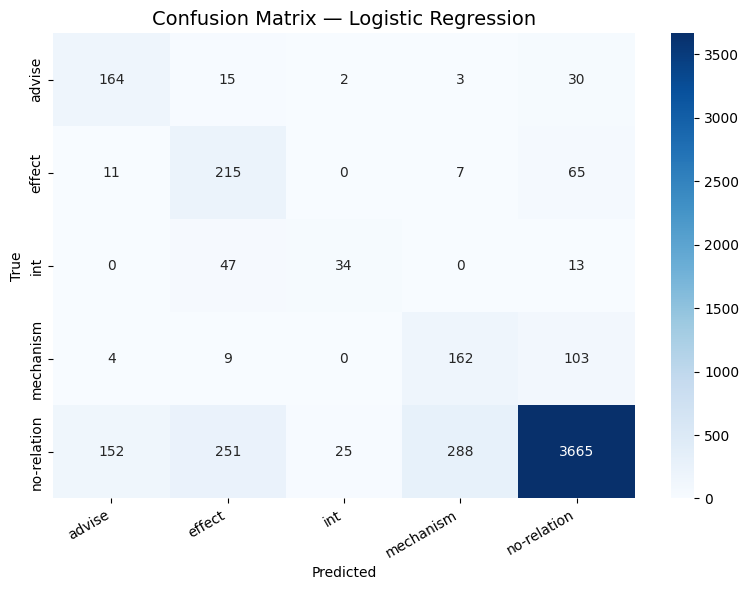

Saved → results/re_confusion_matrix.png


In [ ]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 're_confusion_matrix.png'), dpi=150)
plt.show()
print('Saved → results/re_confusion_matrix.png')

## 7. Top 20 Most Important Features

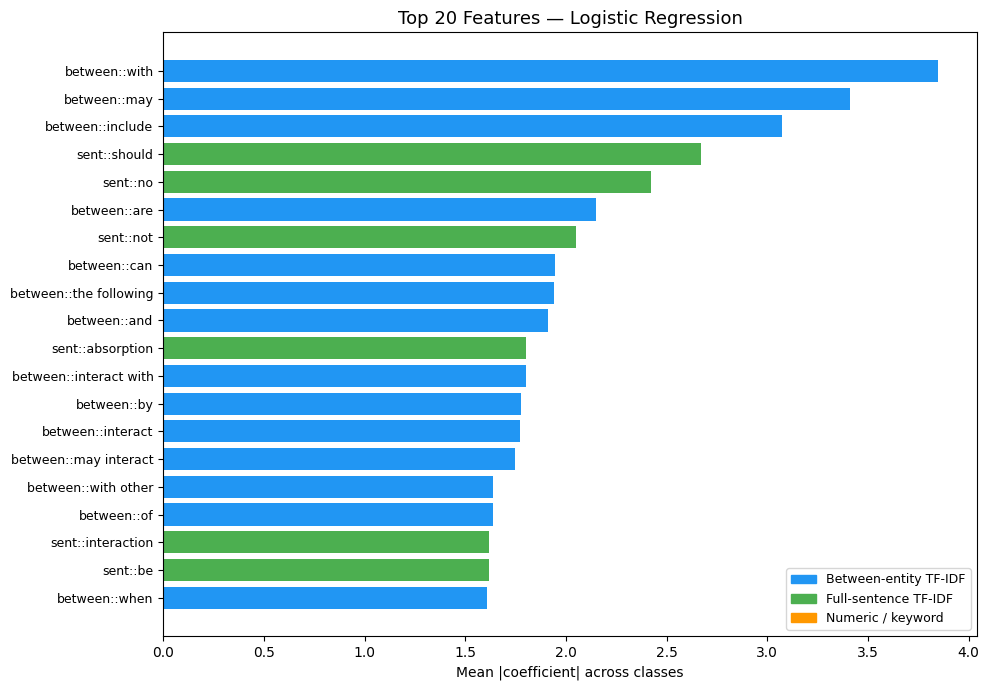

Saved → results/re_feature_importance.png


In [ ]:
# Build the list of all feature names in the same order as the columns in X_train
between_names = [f'between::{t}' for t in tfidf_between.get_feature_names_out()]
sent_names    = [f'sent::{t}'    for t in tfidf_sent.get_feature_names_out()]
num_names     = ['word_count_between', 'sentence_length', 'entity_order'] + \
                [f'kw_{kw}' for kw in KEYWORDS]
all_names = between_names + sent_names + num_names


def plot_top_features(model, model_name, feature_names, top_n=20):
    # Logistic Regression and LinearSVM both expose coef_
    # Random Forest exposes feature_importances_
    if hasattr(model, 'coef_'):
        # For multi-class, coef_ has shape (n_classes, n_features)
        # Average the absolute value across all classes
        importance = np.abs(model.coef_).mean(axis=0)
        xlabel = 'Mean |coefficient| across classes'
    else:
        importance = model.feature_importances_
        xlabel = 'Gini importance'

    # Get indices of top N features sorted by importance
    top_idx   = np.argsort(importance)[::-1][:top_n]
    top_vals  = importance[top_idx]
    top_names = [feature_names[i] for i in top_idx]

    # Color-code bars by feature block
    colors = ['#2196F3' if n.startswith('between') else
              '#4CAF50' if n.startswith('sent')    else '#FF9800'
              for n in top_names]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(top_n), top_vals[::-1], color=colors[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names[::-1], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_title(f'Top {top_n} Features — {model_name}', fontsize=13)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#2196F3', label='Between-entity TF-IDF'),
        Patch(color='#4CAF50', label='Full-sentence TF-IDF'),
        Patch(color='#FF9800', label='Numeric / keyword'),
    ], loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 're_feature_importance.png'), dpi=150)
    plt.show()
    print('Saved → results/re_feature_importance.png')


plot_top_features(best_model, best_name, all_names)

## 8. Save Results

In [ ]:
results_path = os.path.join(RESULTS_DIR, 're_results.json')

# Load existing results file if it exists, else start fresh
if os.path.exists(results_path) and os.path.getsize(results_path) > 0:
    with open(results_path, 'r') as f:
        try:
            all_results = json.load(f)
            if not isinstance(all_results, dict):
                all_results = {}
        except json.JSONDecodeError:
            all_results = {}
else:
    all_results = {}

per_class_f1 = f1_score(y_test, y_pred_best, average=None).tolist()

entry = {
    'task':         'DDI Relation Extraction',
    'best_model':   best_name,
    'features':     'between_tfidf(3000) + sent_tfidf(5000) + numeric(19)',
    'macro_f1':     results_summary[best_name]['macro_f1'],
    'weighted_f1':  results_summary[best_name]['weighted_f1'],
    'per_class_f1': {CLASS_NAMES[i]: round(v, 4) for i, v in enumerate(per_class_f1)},
    'all_models':   results_summary,
    'num_train':    int(len(train_df)),
    'num_test':     int(len(test_df)),
    'label_mapping': {str(k): v for k, v in label2id.items()},
}

all_results['classical_re'] = entry  # upsert — overwrites if key already exists

with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'Results saved to {results_path}')
print(json.dumps(entry, indent=2))

Results saved to /content/drive/MyDrive/biomedical-nlp-project-beta/results/re_results.json
{
  "task": "DDI Relation Extraction",
  "best_model": "Logistic Regression",
  "features": "between_tfidf(3000) + sent_tfidf(5000) + numeric(19)",
  "macro_f1": 0.5765,
  "weighted_f1": 0.8233,
  "per_class_f1": {
    "advise": 0.6018,
    "effect": 0.515,
    "int": 0.4387,
    "mechanism": 0.439,
    "no-relation": 0.8877
  },
  "all_models": {
    "Logistic Regression": {
      "macro_f1": 0.5765,
      "weighted_f1": 0.8233
    },
    "Linear SVM": {
      "macro_f1": 0.5231,
      "weighted_f1": 0.8196
    },
    "Random Forest": {
      "macro_f1": 0.4759,
      "weighted_f1": 0.8431
    }
  },
  "num_train": 26004,
  "num_test": 5265,
  "label_mapping": {
    "advise": 0,
    "effect": 1,
    "int": 2,
    "mechanism": 3,
    "no-relation": 4
  }
}


## 9. Summary

In [ ]:
summary_df = pd.DataFrame([
    {'Model': name, 'Macro F1': v['macro_f1'], 'Weighted F1': v['weighted_f1']}
    for name, v in results_summary.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

display(summary_df.style.highlight_max(subset=['Macro F1', 'Weighted F1'], color='lightgreen'))

print(f'\nBest model : {best_name}')
print(f'Macro F1   : {results_summary[best_name]["macro_f1"]}')
print(f'Weighted F1: {results_summary[best_name]["weighted_f1"]}')
print('\nPer-class F1:')
for cls, val in zip(CLASS_NAMES, per_class_f1):
    print(f'  {cls:20s}: {val:.4f}')

,Model,Macro F1,Weighted F1
0,Logistic Regression,0.576500,0.823300
1,Linear SVM,0.523100,0.819600
2,Random Forest,0.475900,0.843100



Best model : Logistic Regression
Macro F1   : 0.5765
Weighted F1: 0.8233

Per-class F1:
  advise              : 0.6018
  effect              : 0.5150
  int                 : 0.4387
  mechanism           : 0.4390
  no-relation         : 0.8877
